# Titanic Dataset - Exploratory Data Analysis (EDA)

## Introduction

The Titanic dataset contains information about passengers who traveled
on the RMS Titanic.

In this project, we will perform Exploratory Data Analysis (EDA) to
understand the dataset, clean the data, analyze passenger characteristics,
visualize important patterns, and identify factors associated with
passenger survival.

## Objectives

- Understand the structure of the Titanic dataset
- Identify and handle missing values
- Check duplicate records
- Analyze numerical and categorical variables
- Perform univariate analysis
- Perform bivariate analysis
- Perform multivariate analysis
- Analyze outliers
- Study correlations between variables
- Create useful features
- Answer important analytical questions
- Summarize the main findings

## 1. Importing Required Libraries

In this project, we use Pandas and NumPy for data manipulation
and Matplotlib and Seaborn for visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Interpretation

The required Python libraries have been successfully imported.

- Pandas is used for data manipulation.
- NumPy is used for numerical operations.
- Matplotlib is used for creating plots.
- Seaborn is used for statistical data visualization.

## 2. Loading the Dataset

The Titanic dataset is loaded into a Pandas DataFrame.

In [ ]:
df = pd.read_csv("titanic.csv")

## Interpretation

The Titanic dataset has been successfully loaded into a Pandas DataFrame
named `df`.

# Dataset Overview

Before performing any analysis, we first examine the structure,
dimensions, columns, data types, and sample records of the dataset.

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Last 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q



Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## Interpretation

The dataset contains **891 passenger records and 12 variables**.

The dataset includes numerical, categorical, and text-based variables.

The `Survived` column is the target variable, where:
- `0` represents passengers who did not survive.
- `1` represents passengers who survived.

The initial statistical summary provides information about the central
tendency, spread, and distribution of numerical variables and helps
identify variables that require further investigation.

# Data Quality Assessment

Missing values can affect statistical analysis and visualizations.
Therefore, we first identify the number and percentage of missing
values in each column.

In [ ]:
missing_count = df.isnull().sum()

missing_percentage = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


## Interpretation

The dataset contains missing values mainly in `Cabin`, `Age`, and
`Embarked`.

`Cabin` has a very high percentage of missing values, while `Age`
contains a moderate number of missing observations. `Embarked`
contains only a small number of missing values.

These missing values need to be handled appropriately before further
analysis.

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Interpretation

The duplicate check helps ensure that the same passenger record has
not been accidentally repeated in the dataset.

If no duplicate rows are found, the dataset does not require duplicate
removal.

# Data Cleaning

Based on the data quality assessment, missing values and unnecessary
columns will be handled before performing detailed analysis.

The cleaning process should preserve useful information while avoiding
unnecessary modifications to the original data.

In [ ]:
df_clean = df.copy()

In [ ]:
# Fill missing Age values using the median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Fill missing Embarked values using the mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(
    df_clean["Embarked"].mode()[0]
)

# Drop Cabin because of the very high percentage of missing values
df_clean.drop(columns=["Cabin"], inplace=True)

## Interpretation

The following cleaning decisions were applied:

- Missing `Age` values were replaced with the median age.
- Missing `Embarked` values were replaced with the most frequent
  embarkation port.
- `Cabin` was removed because most of its values were missing.

The cleaned dataset is now more suitable for exploratory analysis.

In [ ]:
df_clean.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Interpretation

The missing-value check confirms that the major missing-value issues
identified earlier have been addressed.

# Feature Engineering

Feature engineering involves creating meaningful variables from
existing columns.

For the Titanic dataset, we will create:

- `FamilySize`: Total number of family members traveling together.
- `IsAlone`: Whether the passenger traveled alone.
- `AgeGroup`: Age categories for easier interpretation.
- `FareGroup`: Fare categories for distribution analysis.

In [ ]:
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

df_clean["IsAlone"] = np.where(
    df_clean["FamilySize"] == 1, 1, 0
)

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

df_clean["FareGroup"] = pd.qcut(
    df_clean["Fare"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

## Interpretation

Several new features were created to make the analysis more meaningful.

`FamilySize` represents the total number of family members traveling
with each passenger.

`IsAlone` identifies passengers who traveled without family members.

`AgeGroup` converts continuous age values into meaningful categories.

`FareGroup` divides passengers into four fare categories based on the
distribution of ticket prices.

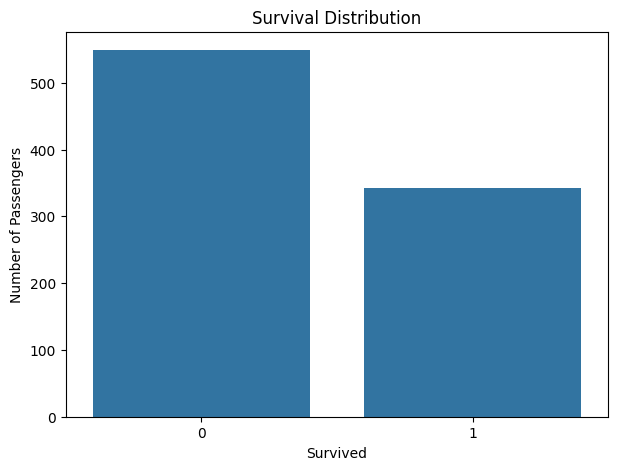

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

## Interpretation

The survival distribution shows that the number of passengers who did
not survive was considerably higher than the number who survived.

This indicates that survival was not evenly distributed among the
passengers.

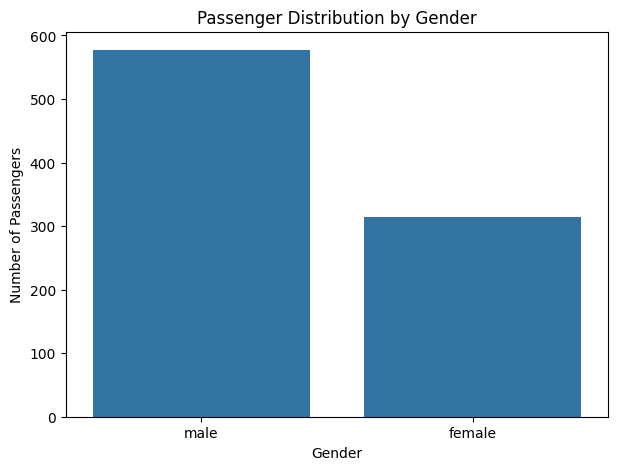

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="Sex")

plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

## Interpretation

The dataset contains both male and female passengers, with male
passengers representing a larger proportion of the dataset.

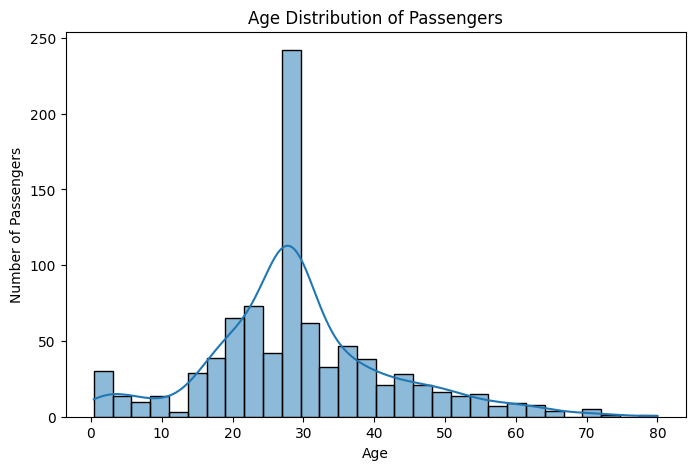

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Interpretation

Passenger ages are distributed across a wide range.

The distribution is concentrated around younger and middle-aged
passengers, while relatively fewer passengers are found at older ages.


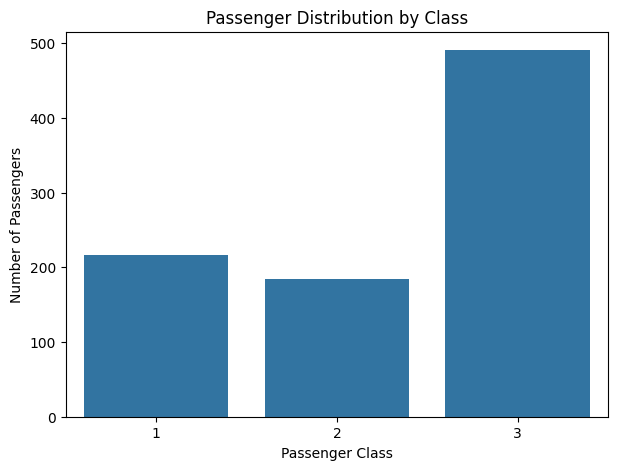

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="Pclass")

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

## Interpretation

Third-class passengers represent the largest passenger group,
followed by second-class and first-class passengers.

Therefore, passenger class is an important variable to investigate
when analyzing survival.

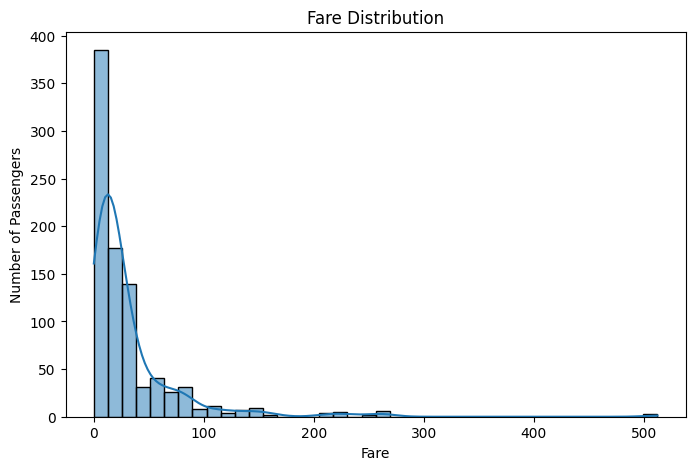

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="Fare",
    bins=40,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

## Interpretation

The fare distribution is strongly right-skewed.

Most passengers paid relatively lower fares, while a smaller number
of passengers paid considerably higher fares.

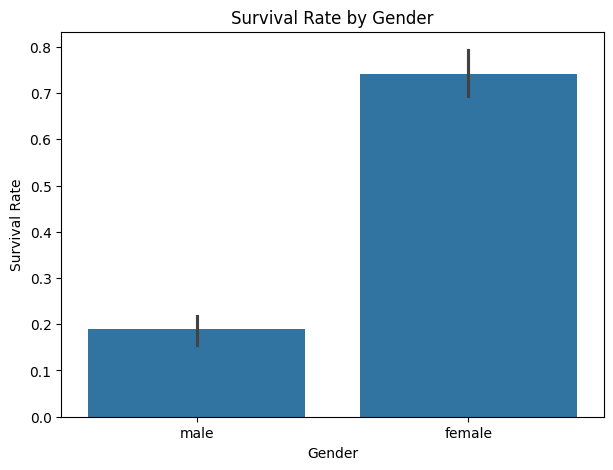

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="Sex",
    y="Survived"
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

## Interpretation

The survival rate differs substantially between male and female
passengers.

Female passengers had a considerably higher survival rate than male
passengers in the Titanic dataset.

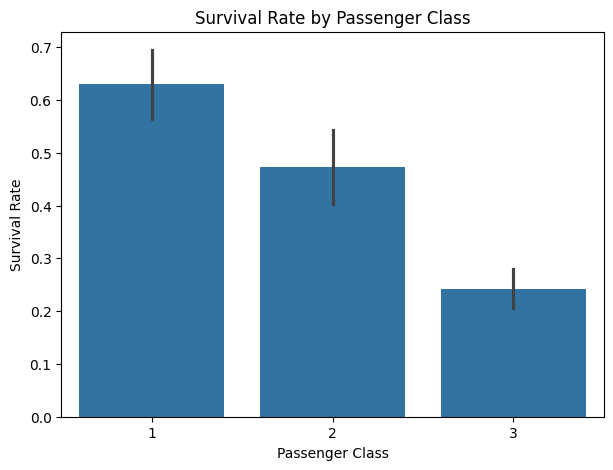

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="Pclass",
    y="Survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

## Interpretation

Survival rates vary considerably across passenger classes.

First-class passengers had the highest survival rate, while
third-class passengers had the lowest survival rate.

This suggests that passenger class was strongly associated with
survival.

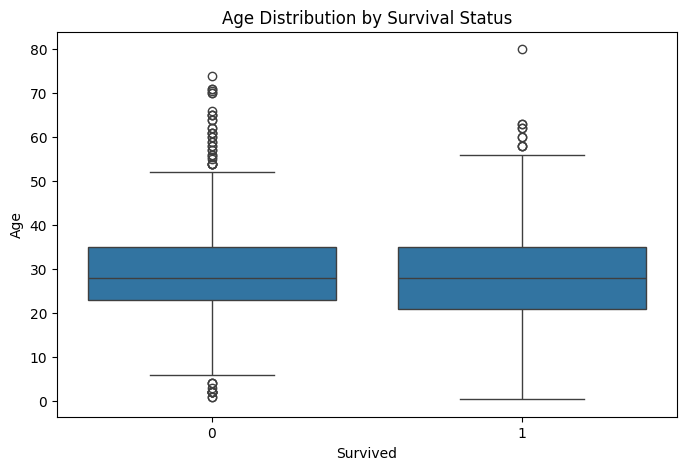

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.show()

## Interpretation

The age distributions of survivors and non-survivors overlap
considerably.

However, younger passengers are represented among survivors,
indicating that age may have some relationship with survival.

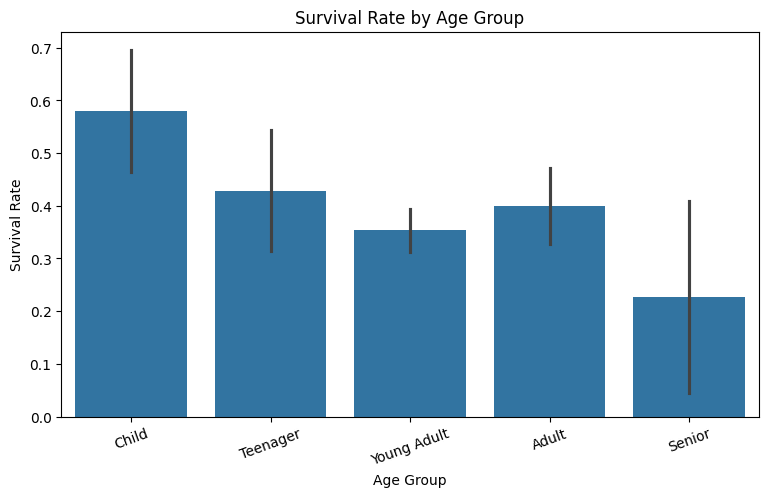

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_clean,
    x="AgeGroup",
    y="Survived"
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.xticks(rotation=20)

plt.show()

## Interpretation

Survival rates vary across age groups.

Younger passengers show different survival patterns compared with
adult and senior passengers.

Age therefore provides additional information when studying survival.

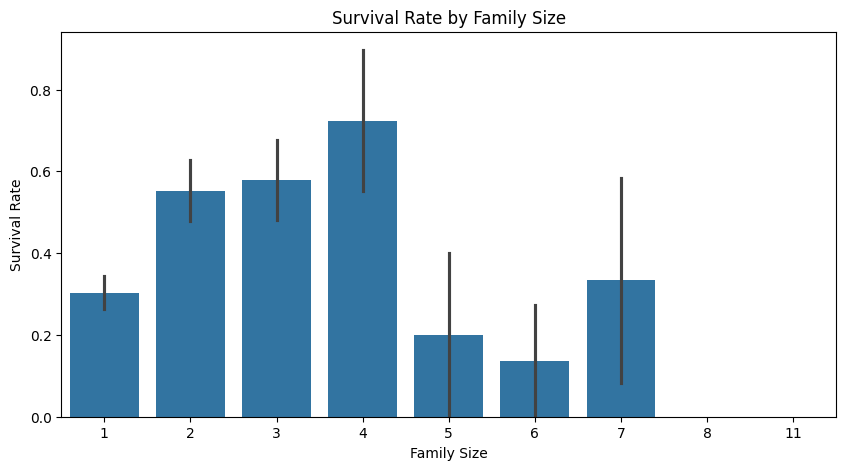

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_clean,
    x="FamilySize",
    y="Survived"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

## Interpretation

Survival rates vary according to family size.

Passengers traveling with a small number of family members generally
show different survival patterns from passengers traveling alone or
with very large families.

This indicates that family structure may have played a role in
passenger survival.

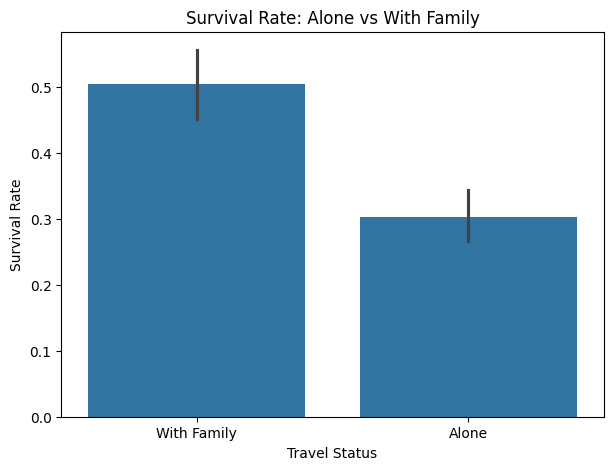

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="IsAlone",
    y="Survived"
)

plt.title("Survival Rate: Alone vs With Family")
plt.xlabel("Travel Status")
plt.ylabel("Survival Rate")

plt.xticks(
    [0, 1],
    ["With Family", "Alone"]
)

plt.show()

## Interpretation

Passengers traveling alone and passengers traveling with family
show different survival rates.

This suggests that traveling status is another potentially important
factor associated with survival.

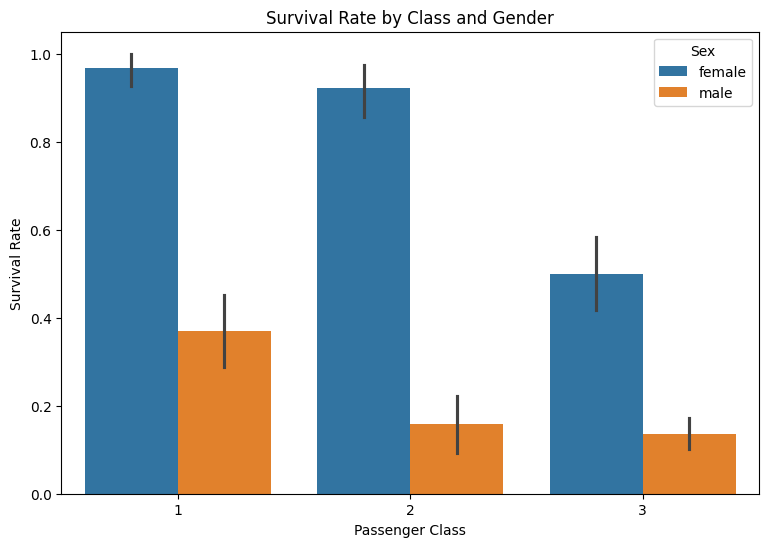

In [ ]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df_clean,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

## Interpretation

The relationship between passenger class and survival differs by
gender.

Female passengers generally show higher survival rates across
passenger classes, while male survival rates are substantially lower.

Passenger class and gender therefore provide more information when
considered together than when examined independently.

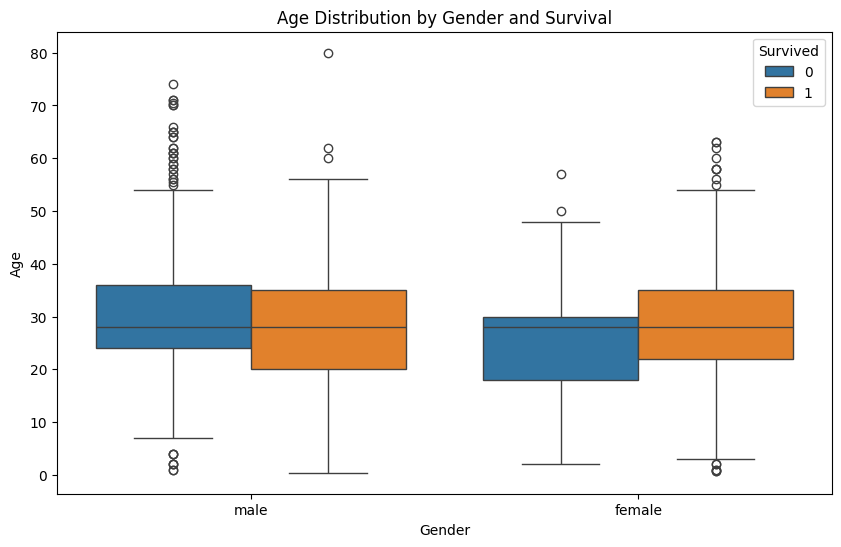

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Sex",
    y="Age",
    hue="Survived"
)

plt.title("Age Distribution by Gender and Survival")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

In [ ]:
## Interpretation

Age distributions differ between survivors and non-survivors within
the male and female groups.

Combining age, gender, and survival helps reveal patterns that may
not be visible when examining each variable separately.

# Correlation Analysis

Correlation analysis helps identify linear relationships between
numerical variables.

A positive correlation means that two variables tend to increase
together, while a negative correlation means that one tends to
increase as the other decreases.

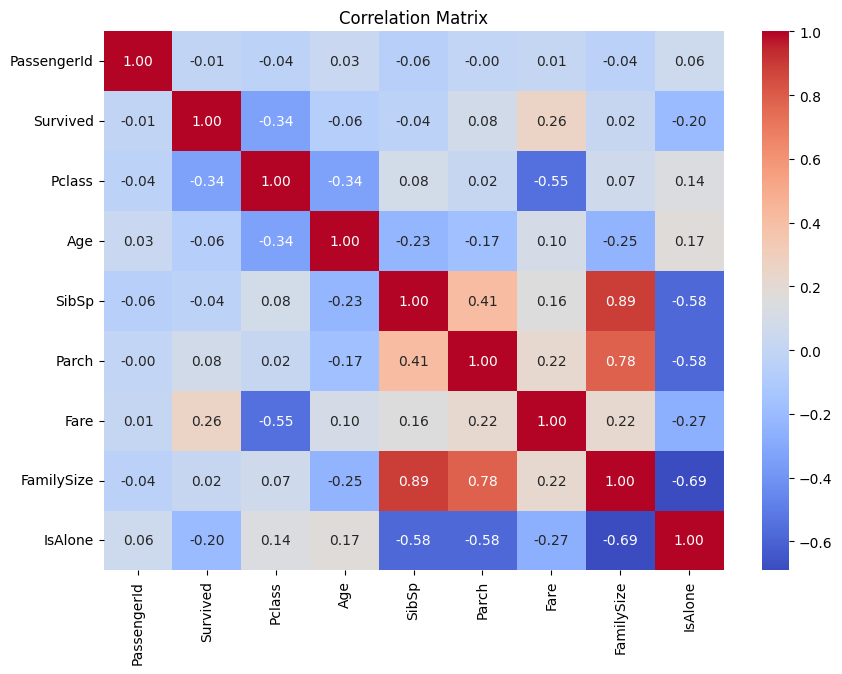

In [ ]:
numeric_df = df_clean.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Interpretation

The correlation matrix shows the relationships among numerical
variables.

`Pclass` has a negative relationship with `Fare` because lower
class numbers represent higher passenger classes.

The correlation between `Survived` and `Pclass` is negative,
indicating that survival generally decreased as the class number
increased.

Correlation does not prove causation, so these relationships should
be interpreted together with the other EDA results.

In [ ]:
survival_rate = df_clean["Survived"].mean() * 100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


## Interpretation

The overall survival rate provides a baseline for comparing survival
across different passenger groups.

In [ ]:
gender_survival = (
    df_clean.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

display(gender_survival)

,Survived
Sex,
female,74.20
male,18.89


## Interpretation

The numerical results confirm the visual analysis.

Female passengers had a substantially higher survival rate than male
passengers.

In [ ]:
class_survival = (
    df_clean.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

display(class_survival)

,Survived
Pclass,
1,62.96
2,47.28
3,24.24


## Interpretation

The numerical results confirm that survival rates differed strongly
across passenger classes.

Higher passenger classes had higher survival rates in this dataset.

# **Question 1 — Who had the highest survival rate?**

In [ ]:
df_clean.groupby("Sex")["Survived"].mean().mul(100).round(2)

,Survived
Sex,
female,74.20
male,18.89


## Finding

Survival rates differed substantially by gender, with female passengers
having a higher observed survival rate than male passengers.

# **Question 2 — Which class had the highest survival rate?**

In [ ]:
df_clean.groupby("Pclass")["Survived"].mean().mul(100).round(2)

,Survived
Pclass,
1,62.96
2,47.28
3,24.24


## Finding

First-class passengers had the highest observed survival rate,
while third-class passengers had the lowest.

# **Question 3 — Did traveling alone matter?**

In [ ]:
df_clean.groupby("IsAlone")["Survived"].mean().mul(100).round(2)

,Survived
IsAlone,
0,50.56
1,30.35


## Finding

Passengers traveling alone and passengers traveling with family
had different observed survival rates, indicating that family
travel status was associated with survival.

# **Key Findings**

# Key Findings

The main findings from the exploratory analysis are:

1. The Titanic dataset contains 891 passenger records and 12 original
   variables.

2. The dataset contains missing values, particularly in `Cabin` and
   `Age`.

3. Female passengers had a substantially higher survival rate than
   male passengers.

4. Passenger class was strongly associated with survival.

5. First-class passengers had the highest observed survival rate,
   while third-class passengers had the lowest.

6. Passenger age showed differences between survivors and
   non-survivors, although the distributions overlap.

7. Family size and traveling-alone status showed differences in
   survival patterns.

8. Fare was strongly associated with passenger class.

9. The correlation analysis identified relationships among several
   numerical variables, but correlation should not be interpreted
   as causation.

# **Final Conclusion**

# Conclusion

This exploratory data analysis provided a detailed understanding of
the Titanic dataset and the factors associated with passenger survival.

The analysis showed that gender and passenger class were among the
most noticeable variables associated with survival. Age, family
structure, and fare also provided useful information about passenger
groups.

Data cleaning and feature engineering improved the quality and
interpretability of the analysis.

Overall, EDA helped uncover important patterns in the Titanic dataset
through statistical summaries, visualizations, and grouped analysis.

These findings can provide a strong foundation for a future machine
learning model that predicts passenger survival.

# **Final Dataset Check**

In [ ]:
print("Final Dataset Shape:", df_clean.shape)

print("\nMissing Values:")
display(df_clean.isnull().sum())

print("\nData Types:")
display(df_clean.dtypes)

print("\nFinal Dataset Preview:")
display(df_clean.head())

Final Dataset Shape: (891, 15)

Missing Values:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



Data Types:


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Final Dataset Preview:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Young Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Adult,Very High
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Young Adult,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Young Adult,Very High
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Young Adult,Medium


# Final Check

The final dataset was checked for its shape, missing values, data
types, and sample records.

The dataset is now clean and ready for further statistical analysis
or machine learning modeling.